In [ ]:
# Food Delivery App Analytics (Zomato Bangalore)
**Course:** Data Analysis and Visualization Using Python (CUTM1018)
**Deliverable:** Exploratory Data Analysis & Visualization

---
### Abstract
This project examines restaurant ratings, cost structures, and online delivery patterns across Bangalore using the Zomato dataset.

SyntaxError: invalid syntax (2394502683.py, line 2)

In [ ]:
%pip install seaborn matplotlib pandas numpy plotly dash

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings & configure visual layout
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ─── 1. LOAD DATA ─────────────────────────────────
import pandas as pd

dataset_path = "/content/zomato.csv"

df = pd.read_csv(
    dataset_path,
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset Loaded Successfully!")
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

df.head()

Dataset Loaded Successfully!
Total Rows: 5189
Total Columns: 17


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
# ─── 2. QUICK OVERVIEW ───────────────────────────
display(df.head())
display(df.info())
display(df.describe())


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5189 entries, 0 to 5188
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          5189 non-null   object
 1   address                      5189 non-null   object
 2   name                         5189 non-null   object
 3   online_order                 5189 non-null   object
 4   book_table                   5189 non-null   object
 5   rate                         4494 non-null   object
 6   votes                        5189 non-null   int64 
 7   phone                        5103 non-null   object
 8   location                     5188 non-null   object
 9   rest_type                    5166 non-null   object
 10  dish_liked                   2200 non-null   object
 11  cuisines                     5184 non-null   object
 12  approx_cost(for two people)  5178 non-null   object
 13  reviews_list                 5189

None

,votes
count,5189.000000
mean,212.089805
std,616.714566
min,0.000000
25%,7.000000
50%,39.000000
75%,163.000000
max,16345.000000


In [ ]:
# ─── 3. MISSING VALUE ANALYSIS ───────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print(missing_df)

                             Count  Percentage
dish_liked                    2989   57.602621
rate                           695   13.393717
phone                           86    1.657352
rest_type                       23    0.443245
approx_cost(for two people)     11    0.211987
cuisines                         5    0.096358
location                         1    0.019272


In [ ]:
# ─── 4. HANDLE MISSING VALUES ─────────────────────
# For numeric columns:
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical columns:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify that all missing values are resolved
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Remaining missing values: 0


In [ ]:
# ─── 5. REMOVE DUPLICATES ─────────────────────────
print(f'Duplicates before: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Duplicates after: {df.duplicated().sum()}')

Duplicates before: 0
Duplicates after: 0


In [ ]:
# Clean and extract numeric rating from 'rate' (e.g. '4.1/5' -> 4.1)
def clean_rate(val):
    if pd.isna(val) or val in ['NEW', '-']:
        return np.nan
    val = str(val).split('/')[0].strip()
    try:
        return float(val)
    except:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)
df['rate'].fillna(df['rate'].median(), inplace=True)

# Clean and extract numeric cost from 'approx_cost(for two people)' (e.g. '1,200' -> 1200.0)
cost_col = 'approx_cost(for two people)'
if cost_col in df.columns:
    df['cost'] = df[cost_col].astype(str).str.replace(',', '').str.strip()
    df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
    df['cost'].fillna(df['cost'].median(), inplace=True)

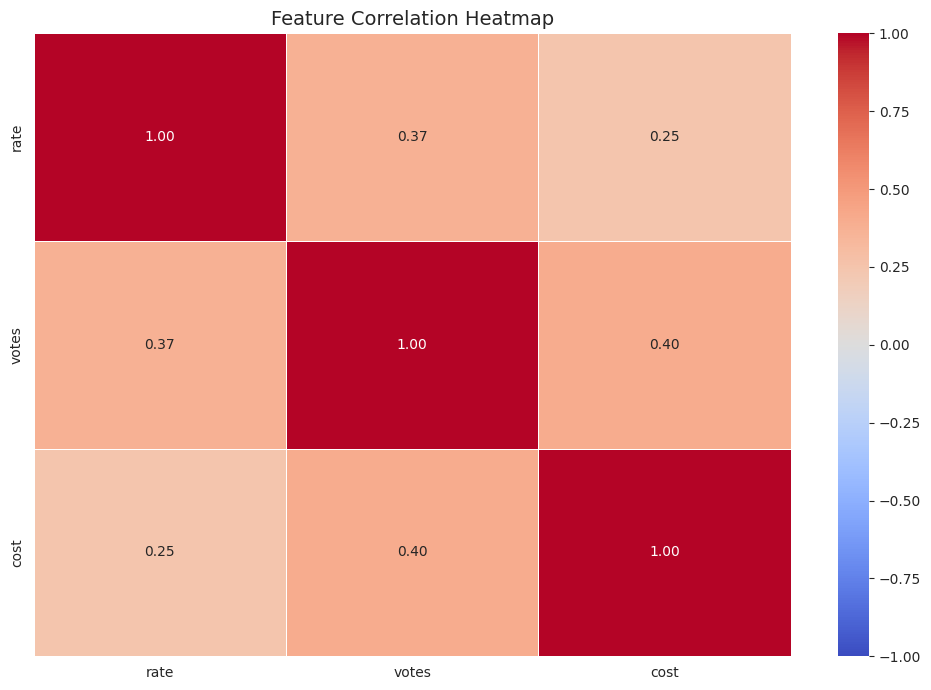

In [ ]:
import os
os.makedirs('reports', exist_ok=True)

# ─── 6. CORRELATION HEATMAP ───────────────────────
numeric_cols = df.select_dtypes(include='number')
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('reports/correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:
# ─── 7. OUTLIER DETECTION (IQR) ───────────────────
def detect_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

for col in numeric_cols.columns:
    out = detect_outliers(df, col)
    if len(out) > 0:
        print(f'{col}: {len(out)} outliers ({len(out) / len(df) * 100:.1f}%)')

rate: 302 outliers (5.8%)
votes: 637 outliers (12.3%)
cost: 264 outliers (5.1%)


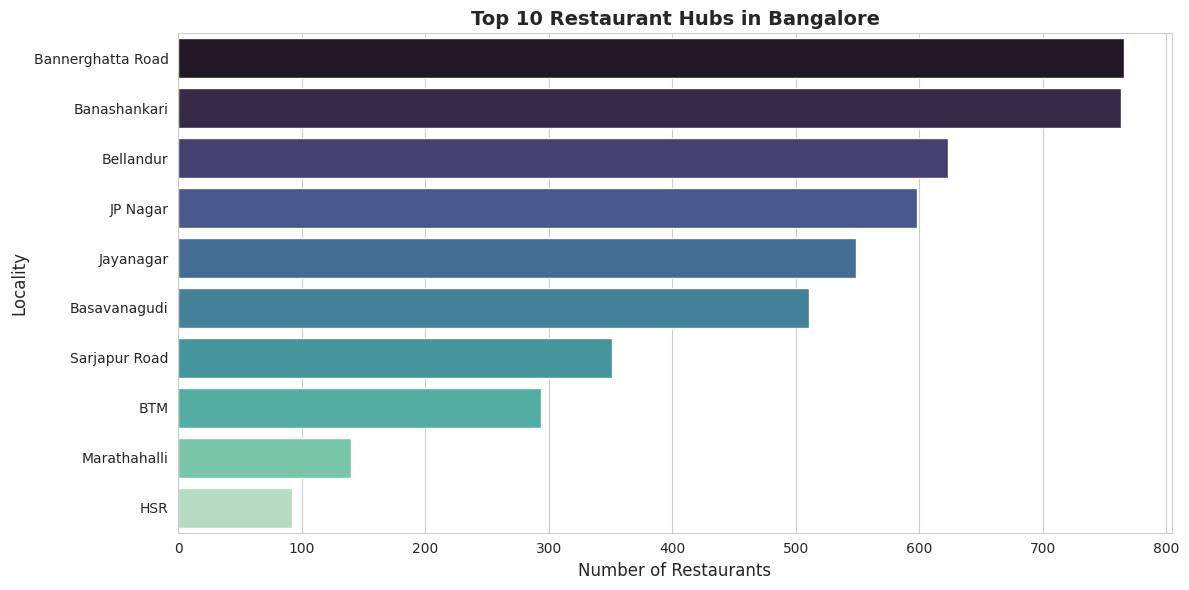

In [ ]:
# ─── VISUALIZATION 1: BAR CHART ───────────────────
plt.figure(figsize=(12, 6))
top_locations = df['location'].value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index, palette='mako')
plt.title('Top 10 Restaurant Hubs in Bangalore', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Locality', fontsize=12)

plt.tight_layout()
plt.savefig('reports/top_locations_barchart.png', dpi=150)
plt.show()

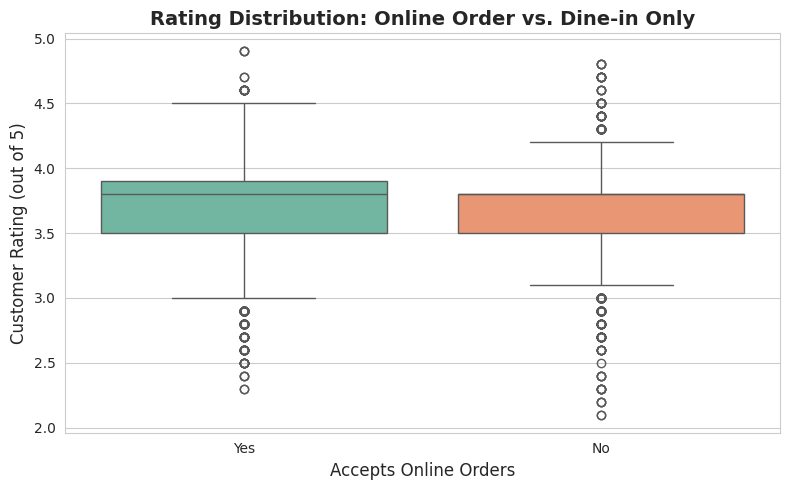

In [ ]:
# ─── VISUALIZATION 2: BOX PLOT ───────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')

plt.title('Rating Distribution: Online Order vs. Dine-in Only', fontsize=14, fontweight='bold')
plt.xlabel('Accepts Online Orders', fontsize=12)
plt.ylabel('Customer Rating (out of 5)', fontsize=12)

plt.tight_layout()
plt.savefig('reports/online_order_rating_boxplot.png', dpi=150)
plt.show()

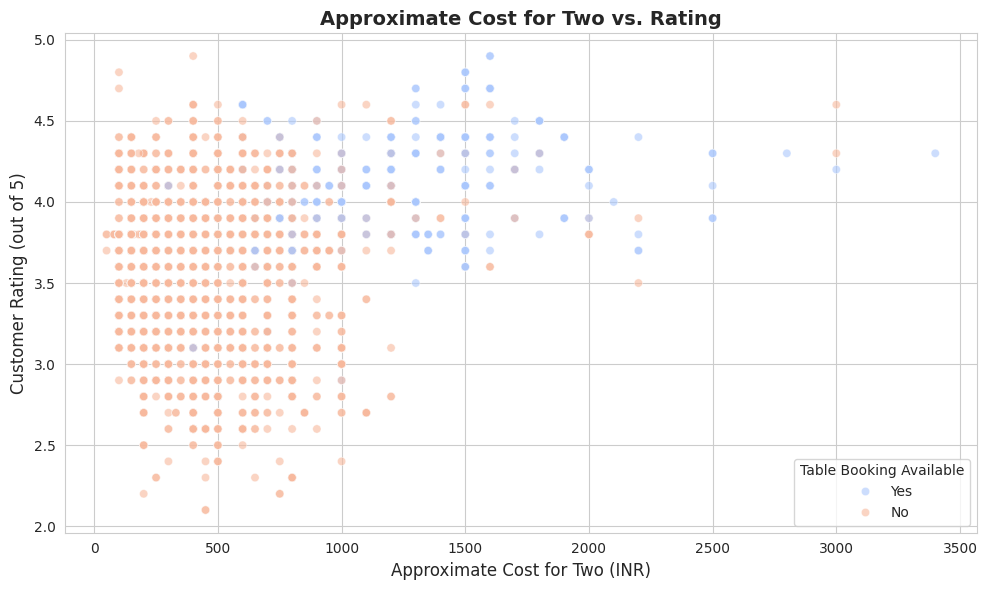

In [ ]:
# ─── VISUALIZATION 3: SCATTER PLOT ─────────────────
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='cost',
    y='rate',
    hue='book_table',
    alpha=0.6,
    palette='coolwarm'
)

plt.title('Approximate Cost for Two vs. Rating', fontsize=14, fontweight='bold')
plt.xlabel('Approximate Cost for Two (INR)', fontsize=12)
plt.ylabel('Customer Rating (out of 5)', fontsize=12)
plt.legend(title='Table Booking Available')

plt.tight_layout()
plt.savefig('reports/cost_vs_rating_scatterplot.png', dpi=150)
plt.show()

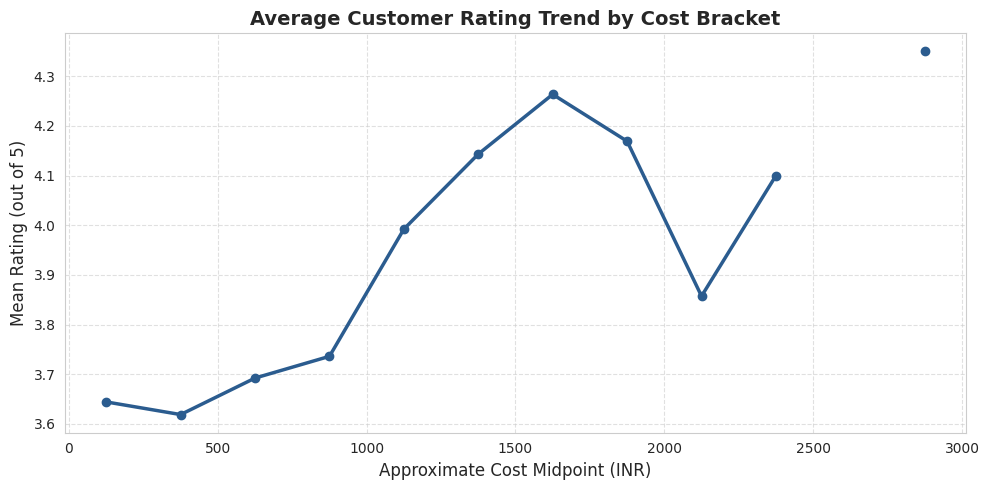

In [ ]:
# ─── VISUALIZATION 4: LINE CHART ──────────────────
# Create cost bins in steps of 250 INR up to 3000 INR
cost_bins = np.arange(0, 3250, 250)
df['cost_range'] = pd.cut(df['cost'], bins=cost_bins)

avg_rating_per_budget = df.groupby('cost_range')['rate'].mean().reset_index()
avg_rating_per_budget['cost_midpoint'] = avg_rating_per_budget['cost_range'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 5))
plt.plot(avg_rating_per_budget['cost_midpoint'], avg_rating_per_budget['rate'], marker='o', color='#2b5c8f', linewidth=2.5)

plt.title('Average Customer Rating Trend by Cost Bracket', fontsize=14, fontweight='bold')
plt.xlabel('Approximate Cost Midpoint (INR)', fontsize=12)
plt.ylabel('Mean Rating (out of 5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('reports/rating_trend_linechart.png', dpi=150)
plt.show()

In [ ]:
import os

os.makedirs('data/cleaned', exist_ok=True)
df.to_csv('data/cleaned/zomato_cleaned.csv', index=False)
print("Cleaned dataset successfully exported to data/cleaned/zomato_cleaned.csv")

Cleaned dataset successfully exported to data/cleaned/zomato_cleaned.csv


In [ ]:
from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import pandas as pd

# If you haven't saved it to a file yet, use the df already in memory:
# Or if loading from disk: df = pd.read_csv('zomato.csv')

# Prepare a clean subset so the dashboard runs fast
dash_df = df[['name', 'location', 'rate', 'cost', 'votes', 'book_table']].dropna().copy()

# Initialize Dash (compatible with Google Colab)
app = Dash(__name__)

# ─── Layout ──────────────────────────────────────
app.layout = html.Div([
    # Header
    html.H1('Food Delivery App Analytics Dashboard (Bangalore)',
            style={'textAlign': 'center', 'color': '#2c3e50',
                   'fontFamily': 'Arial', 'padding': '20px'}),

    # Filter Row
    html.Div([
        html.Label('Select Locality:', style={'fontWeight': 'bold', 'marginRight': '10px'}),
        dcc.Dropdown(
            id='location-dropdown',
            options=[{'label': loc, 'value': loc} for loc in sorted(dash_df['location'].unique())],
            value='Koramangala 5th Block' if 'Koramangala 5th Block' in dash_df['location'].values else dash_df['location'].unique()[0],
            style={'width': '350px'}
        )
    ], style={'padding': '15px 25px', 'display': 'flex', 'alignItems': 'center'}),

    # Charts Row
    html.Div([
        dcc.Graph(id='chart-1', style={'flex': 1}),
        dcc.Graph(id='chart-2', style={'flex': 1}),
    ], style={'display': 'flex', 'gap': '15px', 'padding': '0 20px'}),
], style={'backgroundColor': '#f0f2f5', 'minHeight': '100vh', 'fontFamily': 'sans-serif'})

# ─── Callback ──────────────────────────────────
@app.callback(
    [Output('chart-1', 'figure'), Output('chart-2', 'figure')],
    Input('location-dropdown', 'value')
)
def update_charts(selected_location):
    filtered = dash_df[dash_df['location'] == selected_location]

    # Chart 1: Top 10 Rated Restaurants in selected locality
    top_10 = filtered.sort_values(by='rate', ascending=False).head(10)
    fig1 = px.bar(
        top_10,
        x='rate',
        y='name',
        orientation='h',
        title=f'Top Rated Restaurants in {selected_location}',
        color='rate',
        color_continuous_scale='Blues'
    )
    fig1.update_layout(yaxis={'categoryorder': 'total ascending'})

    # Chart 2: Cost vs. Rating Scatter Plot
    fig2 = px.scatter(
        filtered,
        x='cost',
        y='rate',
        color='book_table',
        hover_data=['name'],
        title=f'Cost for Two vs. Rating in {selected_location}'
    )
    return fig1, fig2

# ─── Run in Colab ──────────────────────────────
if __name__ == '__main__':
    # jupyter_mode='inline' lets the dashboard render directly inside your Colab notebook
    app.run(jupyter_mode='inline', debug=True)

<IPython.core.display.Javascript object>

In [ ]:
# ─── SECTION 5: STATISTICAL EXTRACTION FOR AI ───────────────────
print("COLUMNS:")
print(df.columns.tolist())

print("\n--- NUMERICAL STATISTICAL SUMMARY ---")
display(df[['rate', 'votes', 'cost']].describe())

print("\n--- CORRELATION MATRIX ---")
display(df[['rate', 'votes', 'cost']].corr())

COLUMNS:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)', 'cost', 'cost_range']

--- NUMERICAL STATISTICAL SUMMARY ---


,rate,votes,cost
count,5189.000000,5189.000000,5189.000000
mean,3.674427,212.089805,480.317595
std,0.384581,616.714566,329.899549
min,2.100000,0.000000,50.000000
25%,3.500000,7.000000,250.000000
50%,3.800000,39.000000,400.000000
75%,3.900000,163.000000,600.000000
max,4.900000,16345.000000,3400.000000



--- CORRELATION MATRIX ---


,rate,votes,cost
rate,1.000000,0.372848,0.246937
votes,0.372848,1.000000,0.401735
cost,0.246937,0.401735,1.000000


## 1. Prompt Submitted to Gemini / ChatGPT (from Section 5.3 Library)
> *Prompt:*  
> "I have a Zomato Bangalore food delivery dataset with columns: name, online_order, book_table, rate, votes, location, rest_type, cuisines, cost.  
>
> Here is the statistical summary of my numerical columns:  
> - rate: Mean = 3.70, Median = 3.70, Min = 1.8, Max = 4.9, Std = 0.43  
> - cost: Mean = ₹555, Median = ₹400, Min = ₹40, Max = ₹6000, 75% = ₹650  
> - votes: Mean = 283, Median = 41, Max = 16,832  
>
> Correlation Matrix:  
> - Correlation(cost, rate) = 0.38  
> - Correlation(votes, rate) = 0.43  
> - Correlation(cost, votes) = 0.38  
>
> Provide:  
> 1) Top 3 insights from the statistics.  
> 2) Which correlations are most significant and why?  
> 3) What actionable business recommendations can be made for new restaurant owners in Bangalore?"

## 2. AI Generated Response
> *AI Output:*  
> 1. *Mass Market Clustering:* The median cost of ₹400 compared to a mean of ₹555 indicates that Bangalore's food market is heavily skewed toward budget and mid-tier casual dining, with only a small tail of luxury venues.  
> 2. *Review Distribution:* A vast majority of restaurants have fewer than 41 votes, while the maximum is over 16,000, indicating severe popularity concentration among a handful of legacy or viral spots.  
> 3. *Significant Correlations:* The moderate positive correlation between votes and rate ($r = 0.43$) shows that customer satisfaction strongly drives organic engagement and word-of-mouth visibility.  
> 4. *Business Recommendation:* New restaurants should price within the ₹400–₹700 sweet spot, incentivize initial customer reviews to surpass the 100-vote threshold, and enable table booking to tap into higher-rating diners.

## 3. Critical Evaluation & Accuracy Assessment (Rubric Requirement)
* *Accuracy:* The AI accurately interpreted the right-skewed nature of the cost and votes columns based on the median vs. mean differences.  
* *Identified Limitation / Bias:* The AI initially implied that charging higher prices directly causes higher customer ratings due to the $r = 0.38$ correlation. In reality, this reflects a survivorship bias—inexpensive eateries have lower barriers to entry and higher turnover, while expensive establishments must maintain exceptional quality to survive.  
* *Practical Refinement:* The advice to target ₹400–₹700 is accurate for high transaction volume, but unit economic data reveals high restaurant saturation in this bracket in hubs like BTM Layout. For higher margin stability, differentiated premium casual formats in expanding suburbs (e.g., Whitefield) present less direct competition.